In [ ]:
import numpy as np
import matplotlib.pyplot as pltx
import tensorflow as tf
from tensorflow.keras import layers, models

In [2]:
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values to [0, 1] and add a channel dimension
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, axis=-1)   # (N, 28, 28, 1)
x_test = np.expand_dims(x_test, axis=-1)

print(f"Train shape: {x_train.shape}, Test shape: {x_test.shape}")

Train shape: (60000, 28, 28, 1), Test shape: (10000, 28, 28, 1)


In [3]:
NOISE_FACTOR = 0.4

def add_noise(images, noise_factor=NOISE_FACTOR):
    noisy = images + noise_factor * np.random.normal(
        loc=0.0, scale=1.0, size=images.shape
    )
    # Clip so pixel values stay valid
    return np.clip(noisy, 0.0, 1.0)

x_train_noisy = add_noise(x_train)
x_test_noisy = add_noise(x_test)


In [4]:
def build_autoencoder():
    input_img = layers.Input(shape=(28, 28, 1))

    # --- Encoder ---
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(input_img)
    x = layers.MaxPooling2D((2, 2), padding="same")(x)          # 14x14
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
    encoded = layers.MaxPooling2D((2, 2), padding="same")(x)    # 7x7

    # --- Decoder ---
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(encoded)
    x = layers.UpSampling2D((2, 2))(x)                          # 14x14
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
    x = layers.UpSampling2D((2, 2))(x)                          # 28x28
    decoded = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same")(x)

    autoencoder = models.Model(input_img, decoded, name="denoising_autoencoder")
    autoencoder.compile(optimizer="adam", loss="binary_crossentropy")
    return autoencoder

autoencoder = build_autoencoder()
autoencoder.summary()

Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
EPOCHS = 20
BATCH_SIZE = 128

history = autoencoder.fit(
    x_train_noisy, x_train,               # input: noisy, target: clean
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
)


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 56ms/step - loss: 0.1566 - val_loss: 0.1051
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 55ms/step - loss: 0.1018 - val_loss: 0.0974
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 54ms/step - loss: 0.0965 - val_loss: 0.0945
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 55ms/step - loss: 0.0935 - val_loss: 0.0916
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 54ms/step - loss: 0.0917 - val_loss: 0.0904
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 30s 64ms/step - loss: 0.0905 - val_loss: 0.0893
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 56ms/step - loss: 0.0896 - val_loss: 0.0886
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 57ms/step - loss: 0.0889 - val_loss: 0.0878
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 56ms/step - loss: 0.0883 - val_loss: 0.0876
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 57ms/step - loss: 0.0878 - val_loss: 0.0870
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 56ms/step - loss: 0.0874 - val_loss: 0.0867
Epoch 12/20
469/469 ━━━━━━━━━━

Final test loss (binary crossentropy): 0.0853
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


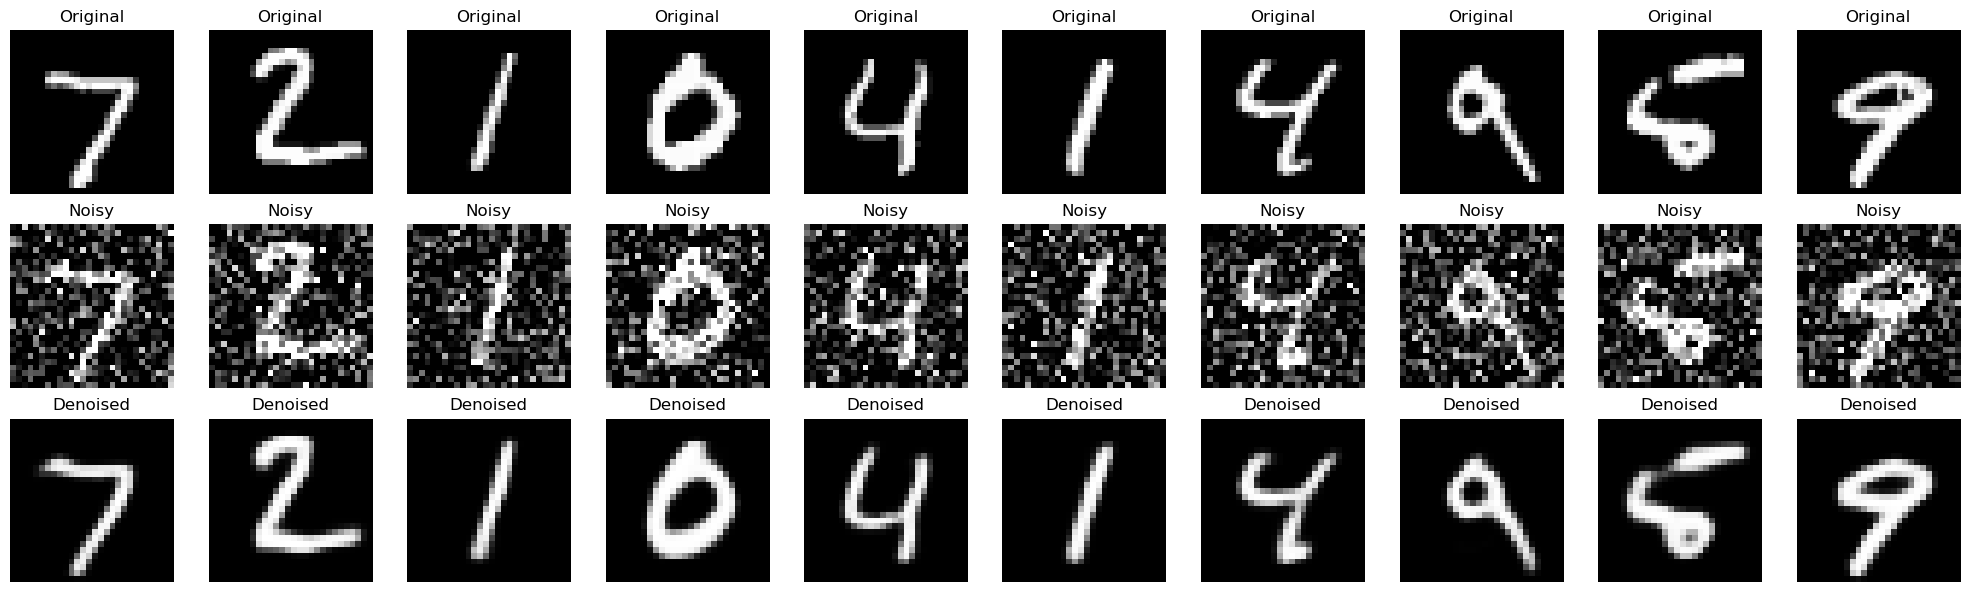

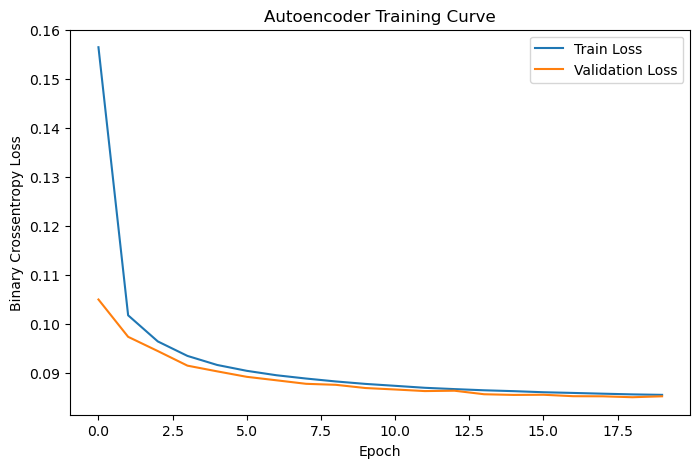

In [6]:
test_loss = autoencoder.evaluate(x_test_noisy, x_test, verbose=0)
print(f"Final test loss (binary crossentropy): {test_loss:.4f}")

decoded_imgs = autoencoder.predict(x_test_noisy)

n = 10  # number of digits to display
plt.figure(figsize=(20, 6))
for i in range(n):
    # Original clean image
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Noisy image (autoencoder input)
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].squeeze(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    # Denoised (autoencoder output)
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(decoded_imgs[i].squeeze(), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.savefig("denoising_results.png", dpi=150)
plt.show()

# Plot training/validation loss curves
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy Loss")
plt.title("Autoencoder Training Curve")
plt.legend()
plt.savefig("training_curve.png", dpi=150)
plt.show()


In [7]:
autoencoder.save("mnist_denoising_autoencoder.h5")
print("Model saved as mnist_denoising_autoencoder.h5")

Model saved as mnist_denoising_autoencoder.h5
